## 1. Imports

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import warnings
from scipy import stats 
import statsmodels.api as sm


from flow_tree_utils import load_test_df, generate_traj_from_path, compute_extended_explore_traj, compute_explore_traj, generate_trajs_from_df, generate_flow_tree_from_trajs, plot_flow_tree

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## 2. Load data

In [3]:
test_df = load_test_df()

## 3. Generate all test-path Flow Trees and backbones

In [4]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    # leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]
    
    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

flow_tree_dict = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    # print("Finding backbone for", path)
    backbone_path, max_weight, weights = get_heaviest_path(G, start_node)
    flow_tree_dict[(start_node, end_node)] = {
        "flow_tree": G,
        "acc": group["path_mean_acc"].iloc[0],
        "backbone_path": backbone_path,
        "backbone_weights": weights
        }
    # print(min(group[group["accuracy"]]["Path.Distance"]))
    if (len(backbone_path[-1])-3) != min(group[group["accuracy"]]["Num.Nodes"]):
        if backbone_path[-1] in ("AGHQTXZP.P", "ICBHQTXZP.P", "KJRUTXZP.P", "LGHQTXZP.P", "NFEDJRUTXZP.P", "OMSRQTXZP.P"): continue
        print(backbone_path[-1])
        print((min(group[group["accuracy"]]["Num.Nodes"])))
        print(group[group["accuracy"]][["paths", "Num.Nodes"]])
    
print(flow_tree_dict)

PZTURJDCBHG.G
7.0
                                          paths  Num.Nodes
19                  P P Z T U U R J D D C C I I        7.0
63                    P P Z T T Q H B B C C I I        7.0
134   P P Z T T Q H B B C D E F F F E D C C I I        7.0
222                   P P Z T T Q H B B C C I I        7.0
334           P P Z T T T T Q Q Q H B B C C I I        7.0
433                   P P Z T T Q H B B C C I I        7.0
521                   P P Z T T Q H B B C C I I        7.0
579     P P Z T U U R J D D C C C B B B C C I I        7.0
633                   P P Z T T Q H B B C C I I        7.0
685                   P P Z T T Q H B B C C I I        7.0
823                   P P Z T T Q H B B C C I I        7.0
871         P P Z T T Q Q R R R R J D D C C I I        7.0
932                 P P Z T U U R J D D C C I I        7.0
1041                  P P Z T T Q H B B C C I I        7.0
1329              P P Z T T Q H B B C C C C I I        7.0
1422          P P Z T T Q H B B C D D 

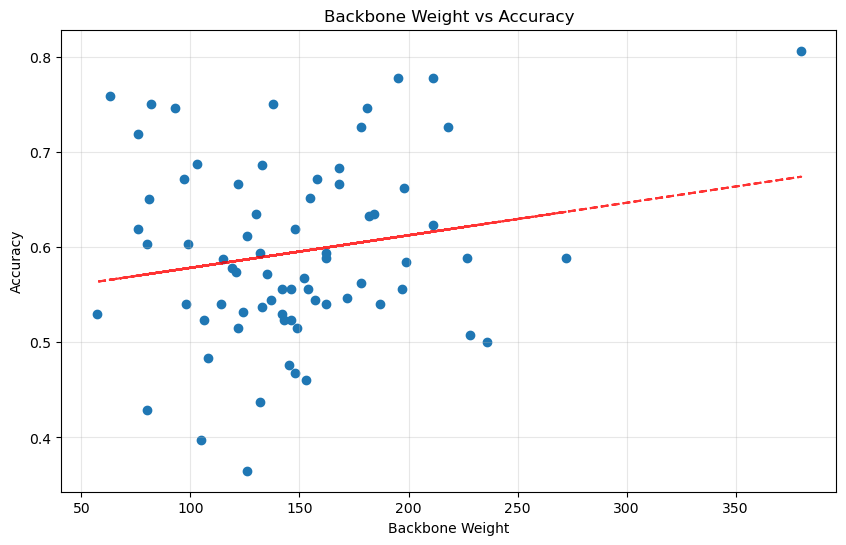

Text(0.05, 0.95, 'r = 0.187\np = 0.116')

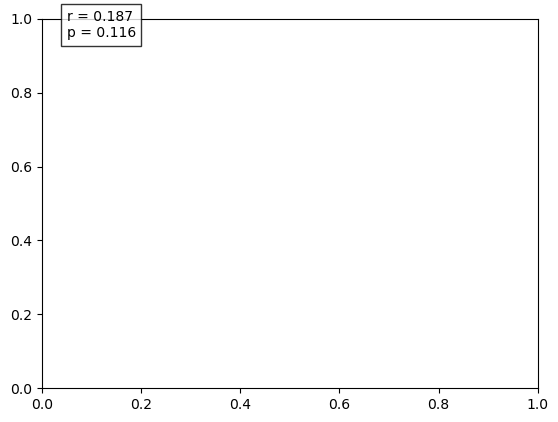

In [5]:
import matplotlib.pyplot as plt

# Extract backbone weights and accuracies
weights = [sum(d["backbone_weights"]) for d in flow_tree_dict.values()]
accs = [d["acc"] for d in flow_tree_dict.values()]

# Create scatter plot
plt.figure(figsize=(10,6))
plt.scatter(weights, accs)
plt.xlabel("Backbone Weight")
plt.ylabel("Accuracy")
plt.title("Backbone Weight vs Accuracy")

# Add trend line
z = np.polyfit(weights, accs, 1)
p = np.poly1d(z)
plt.plot(weights, p(weights), "r--", alpha=0.8)

plt.grid(True, alpha=0.3)
plt.show()

# Calculate correlation coefficient and p-value
from scipy import stats

correlation_coef, p_value = stats.pearsonr(weights, accs)

# Add correlation and p-value text to plot
plt.text(0.05, 0.95, 
         f'r = {correlation_coef:.3f}\np = {p_value:.3f}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))


## 4. Count women v men using backbone

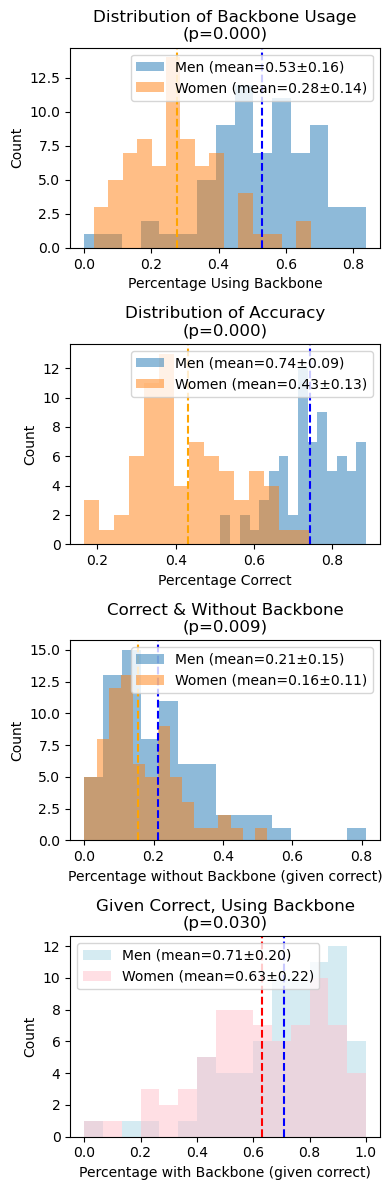

In [6]:
men_using_backbone = []
men_correct = []
men_correct_no_backbone = []
men_correct_with_backbone = []
total_men = []

women_using_backbone = []
women_correct = []
women_correct_no_backbone = []
women_correct_with_backbone = []
total_women = []

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    men_group = group[group["is_man"]]
    women_group = group[~group["is_man"]]

    correct_men_group = men_group[men_group["accuracy"]]
    correct_women_group = women_group[women_group["accuracy"]]

    total_men.append(len(men_group))
    total_women.append(len(women_group))

    men_correct.append(len(correct_men_group))
    women_correct.append(len(correct_women_group))

    backbone_path = flow_tree_dict[(start_node, end_node)]["backbone_path"][-1]
    
    men_trajs = generate_trajs_from_df(men_group)
    men_used_backbone = [backbone_path == "".join(traj) for traj in men_trajs]
    men_using_backbone.append(men_used_backbone)

    women_trajs = generate_trajs_from_df(women_group)
    women_used_backbone = [backbone_path == "".join(traj) for traj in women_trajs]
    women_using_backbone.append(women_used_backbone)

    # Get correct trajectories using backbone
    correct_men_trajs = generate_trajs_from_df(correct_men_group)
    correct_men_with_backbone = [backbone_path == "".join(traj) for traj in correct_men_trajs]
    men_correct_with_backbone.append(correct_men_with_backbone)

    correct_women_trajs = generate_trajs_from_df(correct_women_group)
    correct_women_with_backbone = [backbone_path == "".join(traj) for traj in correct_women_trajs]
    women_correct_with_backbone.append(correct_women_with_backbone)

    # Get correct trajectories not using backbone
    correct_men_no_backbone = [backbone_path != "".join(traj) for traj in correct_men_trajs]
    men_correct_no_backbone.append(correct_men_no_backbone)

    correct_women_no_backbone = [backbone_path != "".join(traj) for traj in correct_women_trajs]
    women_correct_no_backbone.append(correct_women_no_backbone)

    if len(correct_women_group) != sum(correct_women_no_backbone) + sum(correct_women_with_backbone):
        print(f"Correct women group len: {len(correct_women_group)}")
        print(f"Correct women no backbone len: {sum(correct_women_no_backbone)}")
        print(f"Correct women with backbone len: {sum(correct_women_with_backbone)}")
        print(f"Correct women trajs len: {len(correct_women_trajs)}")
        print("AH FUCK")

# Calculate percentages
men_backbone_pct = [sum(x)/total for x, total in zip(men_using_backbone, total_men)]
women_backbone_pct = [sum(x)/total for x, total in zip(women_using_backbone, total_women)]

men_correct_pct = [correct/total for correct, total in zip(men_correct, total_men)]
women_correct_pct = [correct/total for correct, total in zip(women_correct, total_women)]

men_correct_no_backbone_pct = [sum(x)/total for x, total in zip(men_correct_no_backbone, total_men)]
women_correct_no_backbone_pct = [sum(x)/total for x, total in zip(women_correct_no_backbone, total_women)]

men_correct_with_backbone_pct = [sum(x)/total for x, total in zip(men_correct_with_backbone, men_correct)]
women_correct_with_backbone_pct = [sum(x)/total for x, total in zip(women_correct_with_backbone, women_correct)]

# Create figure with four subplots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(4, 12))

# Plot backbone usage distributions and test significance
men_backbone_mean = np.mean(men_backbone_pct)
men_backbone_std = np.std(men_backbone_pct)
women_backbone_mean = np.mean(women_backbone_pct)
women_backbone_std = np.std(women_backbone_pct)
backbone_ttest = stats.ttest_ind(men_backbone_pct, women_backbone_pct)
ax1.hist(men_backbone_pct, alpha=0.5, label=f'Men (mean={men_backbone_mean:.2f}±{men_backbone_std:.2f})', bins=15)
ax1.hist(women_backbone_pct, alpha=0.5, label=f'Women (mean={women_backbone_mean:.2f}±{women_backbone_std:.2f})', bins=15)
ax1.axvline(men_backbone_mean, color='blue', linestyle='--')
ax1.axvline(women_backbone_mean, color='orange', linestyle='--')
ax1.set_title(f'Distribution of Backbone Usage\n(p={backbone_ttest.pvalue:.3f})')
ax1.set_xlabel('Percentage Using Backbone')
ax1.set_ylabel('Count')
ax1.legend()

# Plot accuracy distributions and test significance
men_correct_mean = np.mean(men_correct_pct)
men_correct_std = np.std(men_correct_pct)
women_correct_mean = np.mean(women_correct_pct)
women_correct_std = np.std(women_correct_pct)
accuracy_ttest = stats.ttest_ind(men_correct_pct, women_correct_pct)
ax2.hist(men_correct_pct, alpha=0.5, label=f'Men (mean={men_correct_mean:.2f}±{men_correct_std:.2f})', bins=15)
ax2.hist(women_correct_pct, alpha=0.5, label=f'Women (mean={women_correct_mean:.2f}±{women_correct_std:.2f})', bins=15)
ax2.axvline(men_correct_mean, color='blue', linestyle='--')
ax2.axvline(women_correct_mean, color='orange', linestyle='--')
ax2.set_title(f'Distribution of Accuracy\n(p={accuracy_ttest.pvalue:.3f})')
ax2.set_xlabel('Percentage Correct')
ax2.set_ylabel('Count')
ax2.legend()

# Plot correct but no backbone distributions and test significance
men_no_backbone_mean = np.mean(men_correct_no_backbone_pct)
men_no_backbone_std = np.std(men_correct_no_backbone_pct)
women_no_backbone_mean = np.mean(women_correct_no_backbone_pct)
women_no_backbone_std = np.std(women_correct_no_backbone_pct)
no_backbone_ttest = stats.ttest_ind(men_correct_no_backbone_pct, women_correct_no_backbone_pct)
ax3.hist(men_correct_no_backbone_pct, alpha=0.5, label=f'Men (mean={men_no_backbone_mean:.2f}±{men_no_backbone_std:.2f})', bins=15)
ax3.hist(women_correct_no_backbone_pct, alpha=0.5, label=f'Women (mean={women_no_backbone_mean:.2f}±{women_no_backbone_std:.2f})', bins=15)
ax3.axvline(men_no_backbone_mean, color='blue', linestyle='--')
ax3.axvline(women_no_backbone_mean, color='orange', linestyle='--')
ax3.set_title(f'Correct & Without Backbone\n(p={no_backbone_ttest.pvalue:.3f})')
ax3.set_xlabel('Percentage without Backbone (given correct)')
ax3.set_ylabel('Count')
ax3.legend()

# Plot correct with backbone distributions and test significance
men_with_backbone_mean = np.mean(men_correct_with_backbone_pct)
men_with_backbone_std = np.std(men_correct_with_backbone_pct)
women_with_backbone_mean = np.mean(women_correct_with_backbone_pct)
women_with_backbone_std = np.std(women_correct_with_backbone_pct)
with_backbone_ttest = stats.ttest_ind(men_correct_with_backbone_pct, women_correct_with_backbone_pct)
ax4.hist(men_correct_with_backbone_pct, color="lightblue", alpha=0.5, label=f'Men (mean={men_with_backbone_mean:.2f}±{men_with_backbone_std:.2f})', bins=15)
ax4.hist(women_correct_with_backbone_pct, color="pink", alpha=0.5, label=f'Women (mean={women_with_backbone_mean:.2f}±{women_with_backbone_std:.2f})', bins=15)
ax4.axvline(men_with_backbone_mean, color='blue', linestyle='--')
ax4.axvline(women_with_backbone_mean, color='red', linestyle='--')
ax4.set_title(f'Given Correct, Using Backbone\n(p={with_backbone_ttest.pvalue:.3f})')
ax4.set_xlabel('Percentage with Backbone (given correct)')
ax4.set_ylabel('Count')
ax4.legend()

plt.tight_layout()
plt.show()


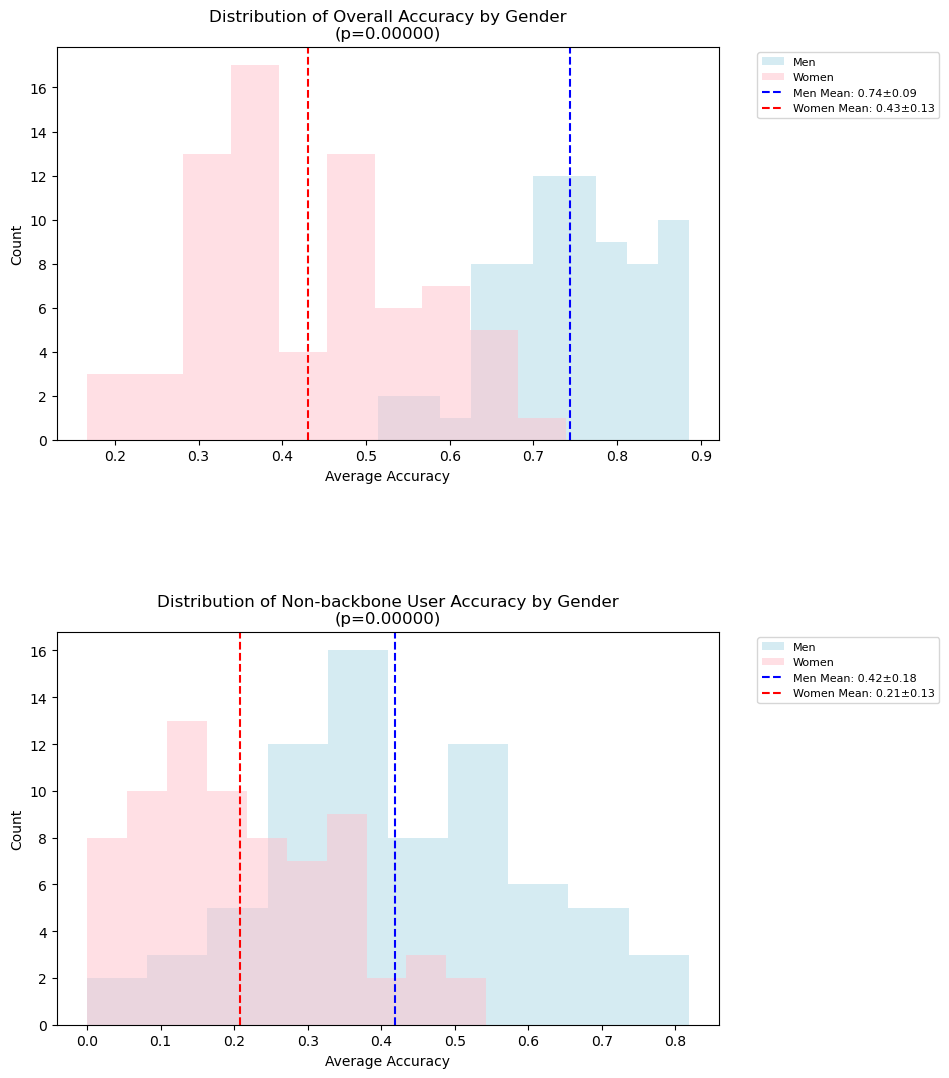

In [7]:
# Calculate accuracy for men and women not using backbone for each path
men_non_backbone_accuracies = []
women_non_backbone_accuracies = []
men_accuracies = []
women_accuracies = []

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    backbone_path = flow_tree_dict[(start_node, end_node)]["backbone_path"][-1]
    
    # Get men's and women's data separately
    men_group = group[group["is_man"]]
    women_group = group[~group["is_man"]]
    
    # Get overall accuracies
    if len(men_group) > 0:
        men_accuracies.append(men_group["accuracy"].mean())
    if len(women_group) > 0:
        women_accuracies.append(women_group["accuracy"].mean())
    
    # Process men's data for non-backbone
    men_trajs = generate_trajs_from_df(men_group)
    men_used_backbone = [backbone_path == "".join(traj) for traj in men_trajs]
    men_non_backbone_mask = ~np.array(men_used_backbone, dtype=bool)
    men_non_backbone_users = men_group[men_non_backbone_mask]
    
    if len(men_non_backbone_users) > 0:
        men_non_backbone_accuracies.append(men_non_backbone_users["accuracy"].mean())
        
    # Process women's data for non-backbone
    women_trajs = generate_trajs_from_df(women_group)
    women_used_backbone = [backbone_path == "".join(traj) for traj in women_trajs]
    women_non_backbone_mask = ~np.array(women_used_backbone, dtype=bool)
    women_non_backbone_users = women_group[women_non_backbone_mask]
    
    if len(women_non_backbone_users) > 0:
        women_non_backbone_accuracies.append(women_non_backbone_users["accuracy"].mean())

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 6))

# Calculate means, stds and run t-tests
men_mean = np.mean(men_accuracies)
men_std = np.std(men_accuracies)
women_mean = np.mean(women_accuracies)
women_std = np.std(women_accuracies)
overall_ttest = stats.ttest_ind(men_accuracies, women_accuracies)

men_mean_acc = np.mean(men_non_backbone_accuracies)
men_std_acc = np.std(men_non_backbone_accuracies)
women_mean_acc = np.mean(women_non_backbone_accuracies)
women_std_acc = np.std(women_non_backbone_accuracies)
nonbackbone_ttest = stats.ttest_ind(men_non_backbone_accuracies, women_non_backbone_accuracies)

# Plot overall accuracies
ax1.hist(men_accuracies, bins=10, alpha=0.5, color='lightblue', label='Men')
ax1.hist(women_accuracies, bins=10, alpha=0.5, color='pink', label='Women')
ax1.set_title(f'Distribution of Overall Accuracy by Gender\n(p={overall_ttest.pvalue:.5f})')
ax1.set_xlabel('Average Accuracy')
ax1.set_ylabel('Count')

# Add mean lines for overall accuracies
ax1.axvline(men_mean, color='blue', linestyle='--', label=f'Men Mean: {men_mean:.2f}±{men_std:.2f}')
ax1.axvline(women_mean, color='red', linestyle='--', label=f'Women Mean: {women_mean:.2f}±{women_std:.2f}')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 8})

# Plot non-backbone accuracies
ax2.hist(men_non_backbone_accuracies, bins=10, alpha=0.5, color='lightblue', label='Men')
ax2.hist(women_non_backbone_accuracies, bins=10, alpha=0.5, color='pink', label='Women')
ax2.set_title(f'Distribution of Non-backbone User Accuracy by Gender\n(p={nonbackbone_ttest.pvalue:.5f})')
ax2.set_xlabel('Average Accuracy')
ax2.set_ylabel('Count')

# Add mean lines for non-backbone accuracies
ax2.axvline(men_mean_acc, color='blue', linestyle='--', label=f'Men Mean: {men_mean_acc:.2f}±{men_std_acc:.2f}')
ax2.axvline(women_mean_acc, color='red', linestyle='--', label=f'Women Mean: {women_mean_acc:.2f}±{women_std_acc:.2f}')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 8})

plt.tight_layout()
plt.gcf().set_size_inches(10, 12)  # Make figure larger
plt.subplots_adjust(right=0.85)    # Adjust right margin to prevent legend cutoff
plt.show()

In [8]:
# Calculate overall accuracy for men and women
men_overall = test_df[test_df['is_man']]['accuracy'].mean()
women_overall = test_df[~test_df['is_man']]['accuracy'].mean()

print(f"Overall accuracy for men: {men_overall:.3f}")
print(f"Overall accuracy for women: {women_overall:.3f}")


Overall accuracy for men: 0.744
Overall accuracy for women: 0.433


## 5. When leave the backbone?

In [9]:
def when_leave_backbone(persons_path, backbone_path):
    # EX Person's path: ['A', 'G', 'H', 'B', 'C', 'I', '.I']
    # EX Backbone path: ['A', 'AGH', 'AGHB', 'AGHBC', 'AGHBCI.I']

    longest_in_backbone = 0
    for i in range(1, len(persons_path)+1):
        if "".join(persons_path[:i]) in backbone_path:
            longest_in_backbone = i
    
    return longest_in_backbone / len(backbone_path[-1])
   
test_df["when_leave_backbone"] = 0
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    backbone_path = flow_tree_dict[(start_node, end_node)]["backbone_path"]

    for i, person in group.iterrows():
        persons_path = person["trajs"]
        when_leave_person = when_leave_backbone(persons_path, backbone_path)
        test_df.at[i, "when_leave_backbone"] = when_leave_person

test_df["subj_mean_leave_backbone"] = test_df.groupby("Subject")["when_leave_backbone"].transform("mean")


In [18]:
def test_backbone_departure_correlation(test_df, only_wrong=False, only_right=False, only_males=False, only_females=False, y_axis=True):
    assert not (only_right and only_wrong)
    assert not (only_males and only_females)
    
    # When leave backbone but only when wrong!
    test_df["when_leave_backbone_wrong"] = pd.NA
    for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
        backbone_path = flow_tree_dict[(start_node, end_node)]["backbone_path"]
        
        for i, person in group.iterrows():
            if (not only_males and not only_females) or (only_males and person["is_man"]) or (only_females and not person["is_man"]):
                
                if (not only_right and not only_wrong) or (only_right and person["accuracy"]) or (only_wrong and not person["accuracy"]):
                    persons_path = person["trajs"]
                    when_leave_person = when_leave_backbone(persons_path, backbone_path)
                    test_df.at[i, "when_leave_backbone_wrong"] = when_leave_person

    test_df["subj_mean_leave_backbone_wrong"] = test_df.groupby("Subject")["when_leave_backbone_wrong"].transform("mean")
    print(test_df[test_df["subj_mean_leave_backbone_wrong"].isna()]["subj_mean_leave_backbone_wrong"])
    backbone_departures = test_df.groupby("Subject")["subj_mean_leave_backbone_wrong"].mean().astype(float)
    print(sum(backbone_departures.isna()))
    print(len(backbone_departures))
    subj_accuracies = test_df.groupby("Subject")["subj_mean_acc"].mean().astype(float)
    sexes = test_df.groupby("Subject")["is_man"].mean().astype(bool)
    
    nas = np.logical_or(backbone_departures.isna(), subj_accuracies.isna())
    backbone_departures_no_na = backbone_departures[~nas]
    subj_accuracies_no_na = subj_accuracies[~nas]
    sex_no_na = sexes[~nas]

    # Create scatter plot of mean backbone departure vs mean accuracy
    fig, ax = plt.subplots(figsize=(5, 5))

    ax.scatter(backbone_departures_no_na,
            subj_accuracies_no_na,
            c=["#2a2d7c" if x else "#FF5A5F" for x in sex_no_na],
            alpha=0.9,
            s=100)
    
    r, p = stats.pearsonr(backbone_departures_no_na, subj_accuracies_no_na)
    print(f"All: r={r:.5f}, p={p:.5f}, n={len(backbone_departures_no_na)}")
    if p < 0.05:
        # Add trend line
        z = np.polyfit(backbone_departures_no_na, subj_accuracies_no_na, 1)
        p = np.poly1d(z)
        ax.plot(backbone_departures_no_na, p(backbone_departures_no_na), 
                "purple", alpha=0.9, linewidth=4)
    
    r, p = stats.pearsonr(backbone_departures_no_na[sex_no_na], subj_accuracies_no_na[sex_no_na])
    print(f"Only males: r={r:.5f}, p={p:.5f}, n={len(backbone_departures_no_na[sex_no_na])}")
    if p < 0.05:
        # Add trend line
        z = np.polyfit(backbone_departures_no_na[sex_no_na], subj_accuracies_no_na[sex_no_na], 1)
        p = np.poly1d(z)
        ax.plot(backbone_departures_no_na[sex_no_na], p(backbone_departures_no_na[sex_no_na]), 
                "#2a2d7c", alpha=0.8, linewidth=4)
    
    r, p = stats.pearsonr(backbone_departures_no_na[~sex_no_na], subj_accuracies_no_na[~sex_no_na])
    print(f"Only females: r={r:.5f}, p={p:.5f}, n={len(backbone_departures_no_na[~sex_no_na])}")
    if p < 0.05:
        # Add trend line
        z = np.polyfit(backbone_departures_no_na[~sex_no_na], subj_accuracies_no_na[~sex_no_na], 1)
        p = np.poly1d(z)
        ax.plot(backbone_departures_no_na[~sex_no_na], p(backbone_departures_no_na[~sex_no_na]), 
                "#FF5A5F", alpha=0.8, linewidth=4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False) 
    ax.spines["bottom"].set_linewidth(2.5)
    plt.xticks([0, 0.3, 0.6, 0.9])
    ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=10)
    print(backbone_departures_no_na[~sex_no_na].mean(), backbone_departures_no_na[~sex_no_na].std())


    # ax.spines["bottom"].set_visible(False)
    # ax.xaxis.set_visible(False)

    if y_axis:
        ax.spines["left"].set_linewidth(2.5)
        # plt.yticks([0.4, 0.6, 0.8])
    else:        
        ax.spines["left"].set_visible(False)
        ax.yaxis.set_visible(False)
    plt.show()

    # compare male v female variances

    sample1 = backbone_departures_no_na[sex_no_na]
    sample2 = backbone_departures_no_na[~sex_no_na]

    # Welch's t-test
    t_stat, p_val = stats.ttest_ind(sample1, sample2, equal_var=False)
    # Welch–Satterthwaite degrees of freedom
    n1 = len(sample1)
    n2 = len(sample2)
    s1_sq = np.var(sample1, ddof=1)
    s2_sq = np.var(sample2, ddof=1)
    numerator = (s1_sq / n1 + s2_sq / n2) ** 2
    denominator = ((s1_sq / n1) ** 2) / (n1 - 1) + ((s2_sq / n2) ** 2) / (n2 - 1)
    dof = numerator / denominator
    print(sample1.mean(), sample1.std(), sample2.mean(), sample2.std())
    print(f"Welch's $t$={t_stat:.3f}, $p$={p_val:.3f}, dof={dof}")

    # Calculate sample variances
    var1 = np.var(sample1, ddof=1)  # ddof=1 for sample variance
    var2 = np.var(sample2, ddof=1)

    # Calculate F-statistic (always larger variance on top)
    if var1 > var2:
        F = var1 / var2
        dfn = len(sample1) - 1
        dfd = len(sample2) - 1
    else:
        F = var2 / var1
        dfn = len(sample2) - 1
        dfd = len(sample1) - 1

    # Two-tailed p-value
    p_value = 2 * min(
        stats.f.cdf(F, dfn, dfd),
        1 - stats.f.cdf(F, dfn, dfd)
    )

    print("F-statistic:", F)
    print("p-value:", p_value)
   

all
Series([], Name: subj_mean_leave_backbone_wrong, dtype: object)
0
97
All: r=0.94809, p=0.00000, n=97
Only males: r=0.92799, p=0.00000, n=51
Only females: r=0.94732, p=0.00000, n=46
0.4433493991917905 0.13160729975369395


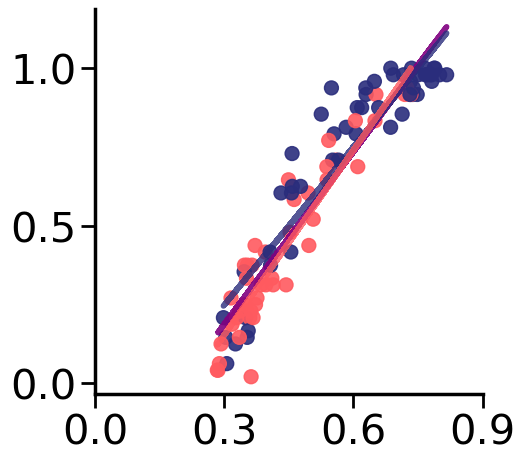

0.5967603089539363 0.16348269573490157 0.4433493991917905 0.13160729975369395
Welch's $t$=5.112, $p$=0.000, dof=93.83702904138309
F-statistic: 1.5430628783956286
p-value: 0.1419694788109962
right
Series([], Name: subj_mean_leave_backbone_wrong, dtype: object)
0
97
All: r=0.46280, p=0.00000, n=97
Only males: r=0.64272, p=0.00000, n=51
Only females: r=0.22313, p=0.13607, n=46
0.6433078145916422 0.11175821048705101


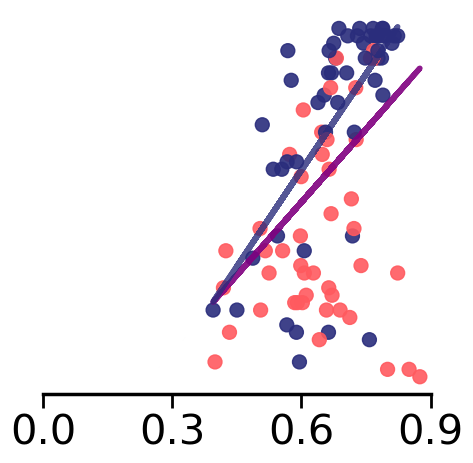

0.678775526865801 0.10488468548919055 0.6433078145916422 0.11175821048705101
Welch's $t$=1.607, $p$=0.112, dof=92.4096001645502
F-statistic: 1.1353629493606976
p-value: 0.6599159357269317
wrong
52      NaN
53      NaN
54      NaN
55      NaN
56      NaN
       ... 
4382    NaN
4383    NaN
4384    NaN
4385    NaN
4386    NaN
Name: subj_mean_leave_backbone_wrong, Length: 240, dtype: object
5
97
All: r=-0.05137, p=0.62674, n=92
Only males: r=-0.07191, p=0.63485, n=46
Only females: r=0.03247, p=0.83039, n=46
0.27985362780429734 0.057183937685788465


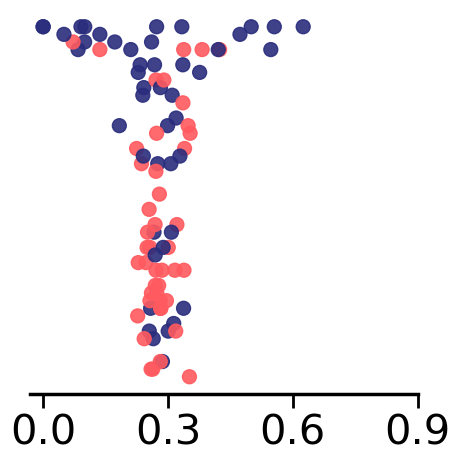

0.27282795678847516 0.1336055868288589 0.27985362780429734 0.057183937685788465
Welch's $t$=-0.328, $p$=0.744, dof=60.95168184853957
F-statistic: 5.458849520888998
p-value: 7.913335009490652e-08


In [19]:
print("all")
test_backbone_departure_correlation(test_df, only_wrong=False, only_right=False)
print("right")
test_backbone_departure_correlation(test_df, only_wrong=False, only_right=True, y_axis=False)
print("wrong")
test_backbone_departure_correlation(test_df, only_wrong=True, only_right=False, y_axis=False)


Simple t-test (not controlling for accuracy):
t-statistic: 1.612
p-value: 0.110


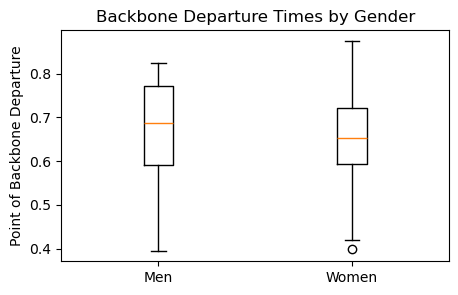


Correlation between gender and accuracy: 0.484 (p=5.124627073266594e-07)

Correlation between gender and backbone departure: 0.163 (p=0.11024780665863956)

Gender Effect on Backbone Departure:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6433      0.016     40.326      0.000       0.612       0.675
x1             0.0355      0.022      1.612      0.110      -0.008       0.079

Accuracy Effect on Backbone Departure:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5686      0.021     27.286      0.000       0.527       0.610
x1             0.1566      0.031      5.089      0.000       0.095       0.218

Full Model (Gender and Accuracy Effects):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------

In [17]:
# When leave backbone but only when right!
test_df["when_leave_backbone_right"] = pd.NA
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    backbone_path = flow_tree_dict[(start_node, end_node)]["backbone_path"]
    
    for i, person in group.iterrows():            
        if person["accuracy"]:
            persons_path = person["trajs"]
            when_leave_person = when_leave_backbone(persons_path, backbone_path)
            test_df.at[i, "when_leave_backbone_right"] = when_leave_person

test_df["subj_mean_leave_backbone_right"] = test_df.groupby("Subject")["when_leave_backbone_right"].transform("mean")

backbone_departures = test_df.groupby("Subject")["subj_mean_leave_backbone_right"].mean().astype(float)
subj_accuracies = test_df.groupby("Subject")["subj_mean_acc"].mean().astype(float)
sexes = test_df.groupby("Subject")["is_man"].mean().astype(bool)

nas = np.logical_or(backbone_departures.isna(), subj_accuracies.isna())
backbone_departures_no_na = backbone_departures[~nas]
subj_accuracies_no_na = subj_accuracies[~nas]
sex_no_na = sexes[~nas]

# Also perform a simple t-test for comparison
men_backbone = backbone_departures_no_na[sex_no_na]
women_backbone = backbone_departures_no_na[~sex_no_na]

t_stat, p_val = stats.ttest_ind(men_backbone, women_backbone)
print("\nSimple t-test (not controlling for accuracy):")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.3f}")

# Create box plot to visualize the difference
plt.figure(figsize=(5, 3))
plt.boxplot([men_backbone, women_backbone], labels=['Men', 'Women'])
plt.ylabel('Point of Backbone Departure')
plt.title('Backbone Departure Times by Gender')
plt.show()

# Perform ANCOVA to compare backbone departure times between men and women
# while controlling for accuracy
import statsmodels.api as sm

# Prepare data for ANCOVA
# Check correlation between gender and accuracy first
gender_acc_corr, p = stats.pearsonr(subj_accuracies_no_na, sex_no_na)
print(f"\nCorrelation between gender and accuracy: {gender_acc_corr:.3f} (p={p})")

# Check correlation between gender and backbone departure
bb_acc_corr, p = stats.pearsonr(backbone_departures_no_na, sex_no_na)
print(f"\nCorrelation between gender and backbone departure: {bb_acc_corr:.3f} (p={p})")

# Since gender and accuracy are moderately correlated (r=0.426), we should run separate models
# First model: Just gender effect
# Run separate models for gender and accuracy effects
X_gender = sex_no_na
X_gender = sm.add_constant(X_gender)
y = backbone_departures_no_na

# Fit gender-only model and print results
model = sm.OLS(np.asarray(y, dtype=float), np.asarray(X_gender, dtype=float)).fit()
print("\nGender Effect on Backbone Departure:")
print(model.summary().tables[1])

# Second model: Just accuracy effect
X_acc = subj_accuracies_no_na
X_acc = sm.add_constant(X_acc)

# Fit accuracy-only model and print results
model_acc = sm.OLS(np.asarray(y, dtype=float), np.asarray(X_acc, dtype=float)).fit()
print("\nAccuracy Effect on Backbone Departure:")
print(model_acc.summary().tables[1])

# Run full model with both predictors
X_full = [[x, y] for (x,y) in zip(backbone_departures_no_na, subj_accuracies_no_na)]
X_full = sm.add_constant(X_full)
y = backbone_departures_no_na

# Fit full model
model_full = sm.OLS(np.asarray(y, dtype=float), np.asarray(X_full, dtype=float)).fit()
print("\nFull Model (Gender and Accuracy Effects):")
print(model_full.summary().tables[1])


Simple t-test (not controlling for accuracy):
t-statistic: 12.509
p-value: 0.000


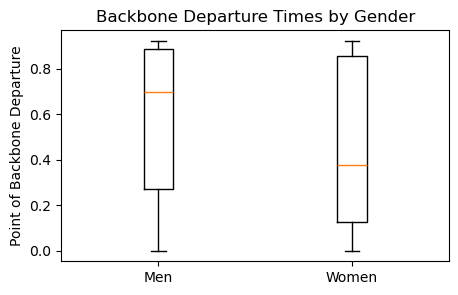


Correlation between gender and accuracy: 0.426

Gender Effect on Backbone Departure:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4352      0.008     56.631      0.000       0.420       0.450
x1             0.1379      0.011     12.509      0.000       0.116       0.159

Accuracy Effect on Backbone Departure:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2239      0.010     21.532      0.000       0.203       0.244
x1             0.4962      0.016     30.529      0.000       0.464       0.528

Full Model (Gender and Accuracy Effects):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2229      0.010     21.3

In [10]:
# Perform t-test to compare backbone departure times between men and women
# while controlling for accuracy using ANCOVA

# import statsmodels.api as sm
# from scipy import stats

# # Prepare data for ANCOVA
# X = merged_test_df[['is_man', 'subj_mean_acc']] # Independent variables
# X = sm.add_constant(X) # Add constant term
# y = merged_test_df['subj_mean_leave_backbone'] # Dependent variable

# # Fit the model
# model = sm.OLS(y, X).fit()

# # Print summary
# print("ANCOVA Results:")
# print(model.summary().tables[1])

# Also perform a simple t-test for comparison
men_backbone = test_df[test_df['is_man']]['when_leave_backbone']
women_backbone = test_df[~test_df['is_man']]['when_leave_backbone']

t_stat, p_val = stats.ttest_ind(men_backbone, women_backbone)
print("\nSimple t-test (not controlling for accuracy):")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.3f}")

# Create box plot to visualize the difference
plt.figure(figsize=(5, 3))
plt.boxplot([men_backbone, women_backbone], labels=['Men', 'Women'])
plt.ylabel('Point of Backbone Departure')
plt.title('Backbone Departure Times by Gender')
plt.show()

# Perform ANCOVA to compare backbone departure times between men and women
# while controlling for accuracy

# Prepare data for ANCOVA
# Check correlation between gender and accuracy first
gender_acc_corr = test_df['is_man'].corr(test_df['subj_mean_acc'])
print(f"\nCorrelation between gender and accuracy: {gender_acc_corr:.3f}")

# Since gender and accuracy are moderately correlated (r=0.426), we should run separate models
# First model: Just gender effect
# Run separate models for gender and accuracy effects
X_gender = test_df[['is_man']]
X_gender = sm.add_constant(X_gender)
y = test_df['when_leave_backbone']

# Fit gender-only model and print results
model = sm.OLS(np.asarray(y, dtype=float), np.asarray(X_gender, dtype=float)).fit()
print("\nGender Effect on Backbone Departure:")
print(model.summary().tables[1])

# Second model: Just accuracy effect
X_acc = test_df[['subj_mean_acc']]
X_acc = sm.add_constant(X_acc)

# Fit accuracy-only model and print results
model_acc = sm.OLS(np.asarray(y, dtype=float), np.asarray(X_acc, dtype=float)).fit()
print("\nAccuracy Effect on Backbone Departure:")
print(model_acc.summary().tables[1])

# Run full model with both predictors
X_full = test_df[['is_man', 'subj_mean_acc']]
X_full = sm.add_constant(X_full)
y = test_df['when_leave_backbone']

# Fit full model
model_full = sm.OLS(np.asarray(y, dtype=float), np.asarray(X_full, dtype=float)).fit()
print("\nFull Model (Gender and Accuracy Effects):")
print(model_full.summary().tables[1])

Key Finding: What initially looked like a gender effect on backbone usage appears to be primarily explained by accuracy differences. When we control for accuracy, the gender effect essentially disappears (becomes non-significant). This suggests that people with higher accuracy tend to stay on the backbone longer, regardless of gender, and the apparent gender difference was mainly due to accuracy differences between men and women.


In simpler terms: It's not really about gender - it's about accuracy. People who are more accurate (who happen to include more men in your sample) tend to stick to the backbone longer.


Is backbone in winner-only flow tree same as in loser-only?